# Model Training Diagnostics Dashboard

This notebook consolidates training telemetry, diagnostics, and parameter-effect views for:
- Single-graph ST-GNN (M3.1)
- Multi-graph fusion ST-GNN (M3.2)

Scientific completeness target: diagnostics for every single graph (SD/DE/DC/ATD), plus both fusion modes (equal and learned), ideally at station and community aggregation.

In [1]:
from pathlib import Path
import ast
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_colwidth', 200)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
EXP_DIR = PROJECT_ROOT / 'data' / 'artifacts' / 'experiments'
STGNN_SINGLE_DIR = EXP_DIR / 'stgnn_single_graph'
STGNN_MILE_DIR = EXP_DIR / 'stgnn_milestones'

def read_csv_if_exists(path: Path) -> pd.DataFrame:
    if not path.exists() or not path.is_file():
        return pd.DataFrame()
    return pd.read_csv(path)

def read_json_if_exists(path: Path) -> dict:
    if not path.exists() or not path.is_file():
        return {}
    return json.loads(path.read_text(encoding='utf-8'))

def load_curve(run_dir: Path) -> pd.DataFrame:
    curve_path = run_dir / 'training_curve.csv'
    if not curve_path.exists():
        return pd.DataFrame()
    curve = pd.read_csv(curve_path)
    curve['run_name'] = run_dir.name
    return curve

def parse_weights(value) -> dict:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return {}
    if isinstance(value, dict):
        return value
    text = str(value).strip()
    if not text:
        return {}
    try:
        parsed = json.loads(text)
    except json.JSONDecodeError:
        try:
            parsed = ast.literal_eval(text)
        except Exception:
            return {}
    return parsed if isinstance(parsed, dict) else {}

In [2]:
milestone_results = read_csv_if_exists(STGNN_MILE_DIR / 'milestone_results.csv')
milestone_best = read_csv_if_exists(STGNN_MILE_DIR / 'milestone_best_by_milestone.csv')
stgnn_single_results = read_csv_if_exists(STGNN_SINGLE_DIR / 'results.csv')
rq_alpha = read_csv_if_exists(EXP_DIR / 'rq_runner' / 'alpha_search.csv')
train_eval_alpha = read_csv_if_exists(EXP_DIR / 'train_eval_3h' / 'train_eval_alpha_search.csv')
baseline_search = read_csv_if_exists(EXP_DIR / 'train_eval_3h' / 'train_eval_baseline_search.csv')
robustness = read_csv_if_exists(EXP_DIR / 'train_eval_3h' / 'station_robustness_statistics.csv')
sensitivity = read_csv_if_exists(EXP_DIR / 'train_eval_3h' / 'sensitivity_summary.csv')

artifact_status = pd.DataFrame([
    {'artifact': 'stgnn_milestones/milestone_results.csv', 'exists': not milestone_results.empty, 'rows': int(len(milestone_results))},
    {'artifact': 'stgnn_milestones/milestone_best_by_milestone.csv', 'exists': not milestone_best.empty, 'rows': int(len(milestone_best))},
    {'artifact': 'stgnn_single_graph/results.csv', 'exists': not stgnn_single_results.empty, 'rows': int(len(stgnn_single_results))},
    {'artifact': 'rq_runner/alpha_search.csv', 'exists': not rq_alpha.empty, 'rows': int(len(rq_alpha))},
    {'artifact': 'train_eval_3h/train_eval_alpha_search.csv', 'exists': not train_eval_alpha.empty, 'rows': int(len(train_eval_alpha))},
    {'artifact': 'train_eval_3h/train_eval_baseline_search.csv', 'exists': not baseline_search.empty, 'rows': int(len(baseline_search))},
    {'artifact': 'train_eval_3h/station_robustness_statistics.csv', 'exists': not robustness.empty, 'rows': int(len(robustness))},
    {'artifact': 'train_eval_3h/sensitivity_summary.csv', 'exists': not sensitivity.empty, 'rows': int(len(sensitivity))},
])

display(artifact_status)

,artifact,exists,rows
0,stgnn_milestones/milestone_results.csv,True,16
1,stgnn_milestones/milestone_best_by_milestone.csv,True,6
2,stgnn_single_graph/results.csv,False,0
3,rq_runner/alpha_search.csv,True,252
4,train_eval_3h/train_eval_alpha_search.csv,True,42
5,train_eval_3h/train_eval_baseline_search.csv,True,42
6,train_eval_3h/station_robustness_statistics.csv,True,28
7,train_eval_3h/sensitivity_summary.csv,True,92


In [3]:
single_present = (
    (not milestone_results.empty and (milestone_results.get('fusion_mode', pd.Series(dtype=str)) == 'single').any())
    or (not stgnn_single_results.empty)
)
multi_present = (
    not milestone_results.empty
    and milestone_results.get('fusion_mode', pd.Series(dtype=str)).isin(['equal', 'learned']).any()
)

versions = []
if single_present:
    versions.append('single-graph ST-GNN (M3.1)')
if multi_present:
    versions.append('multi-graph fusion ST-GNN (M3.2)')

if versions:
    display(Markdown('**Model variants detected:** ' + ', '.join(versions)))
else:
    display(Markdown('**Model variants detected:** none (missing milestone/single artifacts).'))

if not milestone_results.empty:
    cols = [c for c in ['milestone', 'aggregation', 'graph_set', 'fusion_mode', 'epochs_requested', 'epochs_ran', 'best_epoch', 'validation_wmape', 'test_wmape', 'run_dir'] if c in milestone_results.columns]
    display(milestone_results[cols].sort_values([c for c in ['milestone', 'aggregation', 'test_wmape'] if c in cols]))
elif not stgnn_single_results.empty:
    display(stgnn_single_results)
else:
    print('No ST-GNN result table found yet.')

**Model variants detected:** single-graph ST-GNN (M3.1), multi-graph fusion ST-GNN (M3.2)

,milestone,aggregation,graph_set,fusion_mode,epochs_requested,epochs_ran,best_epoch,validation_wmape,test_wmape,run_dir
0,M3.1_single_graph,community,DC,single,40,20,10,0.216016,0.234147,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m31_single_community_dc
1,M3.1_single_graph,community,SD,single,40,20,10,0.216123,0.234235,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m31_single_community_sd
2,M3.1_single_graph,community,ATD,single,40,20,10,0.216077,0.234238,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m31_single_community_atd
3,M3.1_single_graph,community,DE,single,40,20,10,0.216150,0.234284,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m31_single_community_de
6,M3.1_single_graph,station,ATD,single,40,14,1,0.866283,0.862999,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m31_single_station_atd
7,M3.1_single_graph,station,SD,single,40,14,1,0.866733,0.863261,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m31_single_station_sd
8,M3.1_single_graph,station,DE,single,40,14,1,0.867221,0.863689,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m31_single_station_de
9,M3.1_single_graph,station,DC,single,40,14,1,0.878130,0.873936,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m31_single_station_dc
4,M3.2_multi_graph_fusion,community,SD+DE+DC+ATD,learned,40,20,10,0.216062,0.234203,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m32_fusion_learned_community
5,M3.2_multi_graph_fusion,community,SD+DE+DC+ATD,equal,40,20,10,0.216077,0.234218,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m32_fusion_equal_community


### Single-Graph Performance

,aggregation,graph_set,epochs_ran,best_epoch,validation_wmape,test_wmape,run_dir
0,community,DC,20,10,0.216016,0.234147,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m31_single_community_dc
1,community,SD,20,10,0.216123,0.234235,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m31_single_community_sd
2,community,ATD,20,10,0.216077,0.234238,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m31_single_community_atd
3,community,DE,20,10,0.216150,0.234284,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m31_single_community_de
6,station,ATD,14,1,0.866283,0.862999,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m31_single_station_atd
7,station,SD,14,1,0.866733,0.863261,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m31_single_station_sd
14,station,DE,14,1,0.867080,0.863585,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\leakage_leaky_single_de_station
8,station,DE,14,1,0.867221,0.863689,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m31_single_station_de
12,station,DE,14,1,0.867221,0.863689,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\leakage_base_single_de_station
9,station,DC,14,1,0.878130,0.873936,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m31_single_station_dc


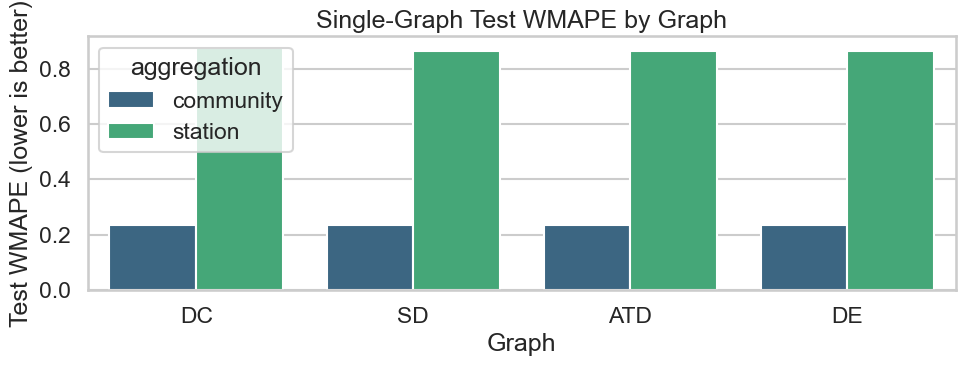

In [4]:
single_rows = pd.DataFrame()
if not milestone_results.empty and 'fusion_mode' in milestone_results.columns:
    single_rows = milestone_results[milestone_results['fusion_mode'] == 'single'].copy()

if single_rows.empty and not stgnn_single_results.empty:
    single_rows = stgnn_single_results.copy()
    if 'run_dir' not in single_rows.columns:
        single_rows['run_dir'] = str(STGNN_SINGLE_DIR)

if single_rows.empty:
    print('No single-graph rows available.')
else:
    display(Markdown('### Single-Graph Performance'))
    cols = [c for c in ['aggregation', 'graph_set', 'epochs_ran', 'best_epoch', 'validation_wmape', 'test_wmape', 'run_dir'] if c in single_rows.columns]
    display(single_rows[cols].sort_values([c for c in ['aggregation', 'test_wmape'] if c in cols]))

    if {'graph_set', 'test_wmape'}.issubset(single_rows.columns):
        plt.figure(figsize=(10, 4))
        sns.barplot(data=single_rows, x='graph_set', y='test_wmape', hue='aggregation' if 'aggregation' in single_rows.columns else None, palette='viridis')
        plt.title('Single-Graph Test WMAPE by Graph')
        plt.xlabel('Graph')
        plt.ylabel('Test WMAPE (lower is better)')
        plt.tight_layout()
        plt.show()

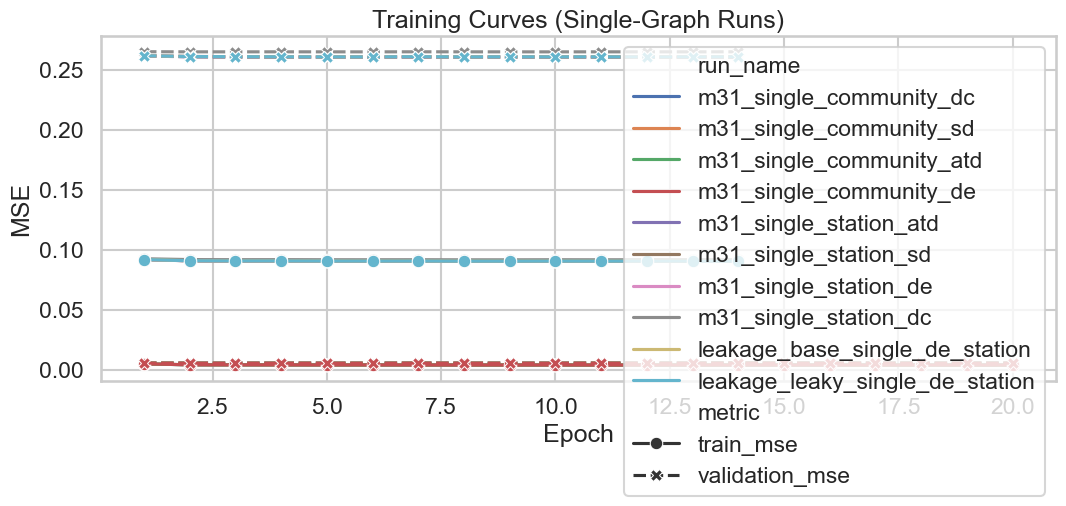

In [5]:
curve_frames = []
candidate_dirs = []

if not single_rows.empty and 'run_dir' in single_rows.columns:
    candidate_dirs.extend([Path(p) for p in single_rows['run_dir'].dropna().astype(str).unique()])

if STGNN_SINGLE_DIR.exists():
    candidate_dirs.append(STGNN_SINGLE_DIR)

seen = set()
for run_dir in candidate_dirs:
    key = str(run_dir.resolve())
    if key in seen:
        continue
    seen.add(key)
    curve = load_curve(run_dir)
    if not curve.empty:
        curve_frames.append(curve)

if not curve_frames:
    print('No single-graph training curves found.')
else:
    curves = pd.concat(curve_frames, ignore_index=True)
    long_curves = curves.melt(id_vars=['epoch', 'run_name'], value_vars=['train_mse', 'validation_mse'], var_name='metric', value_name='value')

    plt.figure(figsize=(11, 5))
    sns.lineplot(data=long_curves, x='epoch', y='value', hue='run_name', style='metric', markers=True, dashes=True)
    plt.title('Training Curves (Single-Graph Runs)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.tight_layout()
    plt.show()

    if int(curves['epoch'].max()) <= 1:
        display(Markdown('Current curves are shallow (max epoch = 1). Re-run with higher epochs/patience for meaningful diagnostics.'))

### Multi-Graph Fusion Performance

,aggregation,graph_set,fusion_mode,epochs_ran,best_epoch,validation_wmape,test_wmape,run_dir
4,community,SD+DE+DC+ATD,learned,20,10,0.216062,0.234203,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m32_fusion_learned_community
5,community,SD+DE+DC+ATD,equal,20,10,0.216077,0.234218,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m32_fusion_equal_community
15,station,SD+DE+DC+ATD,learned,14,1,0.868741,0.865302,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\leakage_leaky_fusion_learned_station
10,station,SD+DE+DC+ATD,learned,14,1,0.868853,0.865387,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m32_fusion_learned_station
13,station,SD+DE+DC+ATD,learned,14,1,0.868853,0.865387,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\leakage_base_fusion_learned_station
11,station,SD+DE+DC+ATD,equal,14,1,0.869484,0.866006,C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\experiments\stgnn_milestones\runs\m32_fusion_equal_station


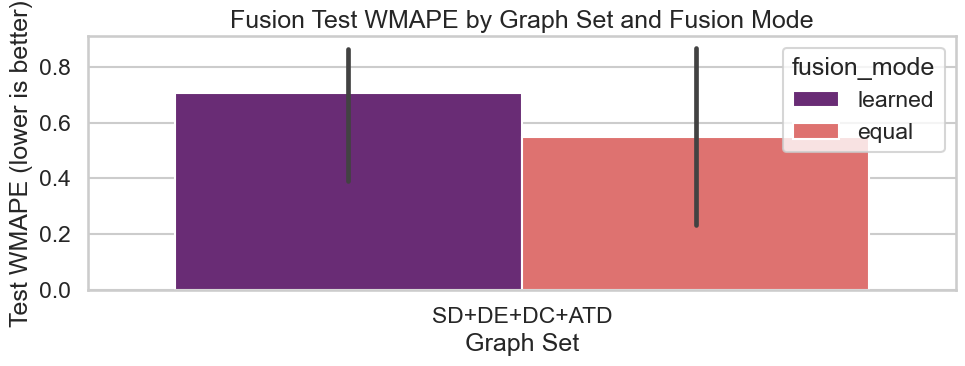

### Learned/Fixed Fusion Weights

,aggregation,graph_set,fusion_mode,graph,weight
7,community,SD+DE+DC+ATD,equal,ATD,0.250000
15,station,SD+DE+DC+ATD,equal,ATD,0.250000
6,community,SD+DE+DC+ATD,equal,DC,0.250000
14,station,SD+DE+DC+ATD,equal,DC,0.250000
5,community,SD+DE+DC+ATD,equal,DE,0.250000
13,station,SD+DE+DC+ATD,equal,DE,0.250000
4,community,SD+DE+DC+ATD,equal,SD,0.250000
12,station,SD+DE+DC+ATD,equal,SD,0.250000
3,community,SD+DE+DC+ATD,learned,ATD,0.222228
11,station,SD+DE+DC+ATD,learned,ATD,0.268055


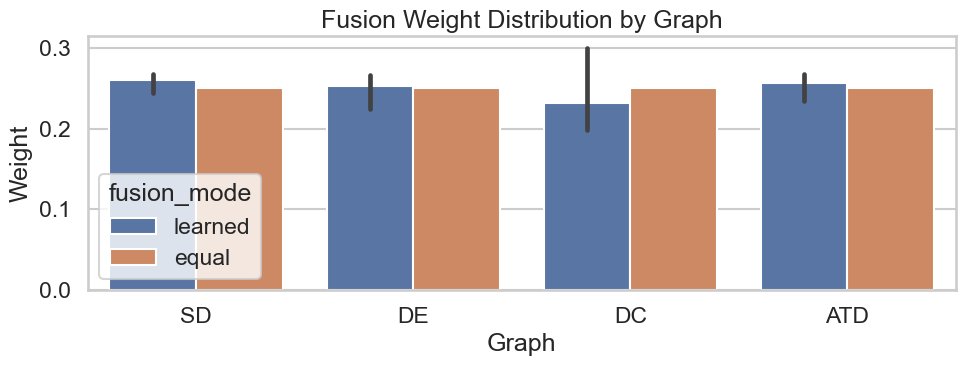

In [6]:
fusion_rows = pd.DataFrame()
if not milestone_results.empty and 'fusion_mode' in milestone_results.columns:
    fusion_rows = milestone_results[milestone_results['fusion_mode'].isin(['equal', 'learned'])].copy()

if fusion_rows.empty:
    print('No multi-graph fusion rows available.')
else:
    display(Markdown('### Multi-Graph Fusion Performance'))
    cols = [c for c in ['aggregation', 'graph_set', 'fusion_mode', 'epochs_ran', 'best_epoch', 'validation_wmape', 'test_wmape', 'run_dir'] if c in fusion_rows.columns]
    display(fusion_rows[cols].sort_values([c for c in ['aggregation', 'graph_set', 'test_wmape'] if c in cols]))

    plt.figure(figsize=(10, 4))
    sns.barplot(data=fusion_rows, x='graph_set', y='test_wmape', hue='fusion_mode', palette='magma')
    plt.title('Fusion Test WMAPE by Graph Set and Fusion Mode')
    plt.xlabel('Graph Set')
    plt.ylabel('Test WMAPE (lower is better)')
    plt.tight_layout()
    plt.show()

    weight_rows = []
    for _, row in fusion_rows.iterrows():
        weights = parse_weights(row.get('fusion_weights'))
        for graph_name, w in weights.items():
            weight_rows.append({
                'aggregation': row.get('aggregation'),
                'graph_set': row.get('graph_set'),
                'fusion_mode': row.get('fusion_mode'),
                'graph': graph_name,
                'weight': float(w),
            })

    weights_df = pd.DataFrame(weight_rows)
    if not weights_df.empty:
        display(Markdown('### Learned/Fixed Fusion Weights'))
        display(weights_df.sort_values(['fusion_mode', 'graph_set', 'graph']))

        plt.figure(figsize=(10, 4))
        sns.barplot(data=weights_df, x='graph', y='weight', hue='fusion_mode', palette='deep')
        plt.title('Fusion Weight Distribution by Graph')
        plt.xlabel('Graph')
        plt.ylabel('Weight')
        plt.tight_layout()
        plt.show()

### Alpha Sensitivity (Parameter Effect)

,index,source,alpha,mean,min
0,0,rq_runner,0.00,19.161063,0.565570
1,1,rq_runner,0.05,9.787527,0.529333
2,2,rq_runner,0.10,5.198973,0.496808
3,3,rq_runner,0.15,2.938868,0.467679
4,4,rq_runner,0.20,1.816924,0.441518
5,5,rq_runner,0.25,1.254585,0.417979
6,6,rq_runner,0.30,0.969580,0.396771
7,7,rq_runner,0.35,0.823551,0.377739
8,8,rq_runner,0.40,0.748283,0.360590
9,9,rq_runner,0.45,0.709876,0.345156


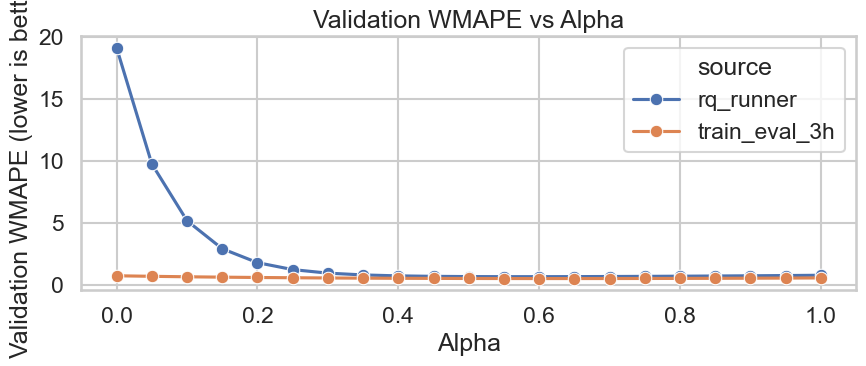

### Baseline Hyperparameter Diagnostics (Top by Validation WMAPE)

,aggregation,graph_set,model,config,validation_wmape,validation_mae,validation_rmse,validation_mase
20,community,"SD,DE,DC,ATD",tree_lagged,"{""lags"": [1, 2, 8, 56], ""max_depth"": 16, ""n_estimators"": 300, ""max_samples"": 300000}",0.214109,59.435535,107.566264,0.584593
10,community,"SD,DE,DC,ATD",tree_lagged,"{""lags"": [1, 2, 8, 56], ""max_depth"": 12, ""n_estimators"": 300, ""max_samples"": 300000}",0.214235,59.470402,107.459619,0.584936
9,community,"SD,DE,DC,ATD",tree_lagged,"{""lags"": [1, 8, 56], ""max_depth"": 12, ""n_estimators"": 300, ""max_samples"": 300000}",0.215337,59.776390,108.188095,0.587945
12,community,"SD,DE,DC,ATD",tree_lagged,"{""lags"": [1, 8, 56], ""max_depth"": 16, ""n_estimators"": 300, ""max_samples"": 300000}",0.216021,59.966260,108.692647,0.589813
11,community,"SD,DE,DC,ATD",tree_lagged,"{""lags"": [1, 2, 8, 56], ""max_depth"": 8, ""n_estimators"": 300, ""max_samples"": 300000}",0.219205,60.849985,109.670541,0.598505
14,community,"SD,DE,DC,ATD",tree_lagged,"{""lags"": [1, 8, 56], ""max_depth"": 8, ""n_estimators"": 300, ""max_samples"": 300000}",0.219214,60.852526,109.685353,0.598530
17,community,"SD,DE,DC,ATD",tree_lagged,"{""lags"": [1, 2, 8], ""max_depth"": 8, ""n_estimators"": 300, ""max_samples"": 300000}",0.227561,63.169607,121.854756,0.621320
16,community,"SD,DE,DC,ATD",tree_lagged,"{""lags"": [1, 2, 8], ""max_depth"": 12, ""n_estimators"": 300, ""max_samples"": 300000}",0.228413,63.406159,124.079316,0.623647
13,community,"SD,DE,DC,ATD",tree_lagged,"{""lags"": [1, 8], ""max_depth"": 8, ""n_estimators"": 300, ""max_samples"": 300000}",0.229710,63.766326,126.056470,0.627189
15,community,"SD,DE,DC,ATD",tree_lagged,"{""lags"": [1, 2, 8], ""max_depth"": 16, ""n_estimators"": 300, ""max_samples"": 300000}",0.230806,64.070443,124.399762,0.630181


In [7]:
alpha_frames = []
if not rq_alpha.empty:
    tmp = rq_alpha[['alpha', 'validation_wmape']].copy()
    tmp['source'] = 'rq_runner'
    alpha_frames.append(tmp)
if not train_eval_alpha.empty:
    tmp = train_eval_alpha[['alpha', 'validation_wmape']].copy()
    tmp['source'] = 'train_eval_3h'
    alpha_frames.append(tmp)

if alpha_frames:
    alpha_all = pd.concat(alpha_frames, ignore_index=True)
    display(Markdown('### Alpha Sensitivity (Parameter Effect)'))
    display(alpha_all.groupby(['source', 'alpha'], as_index=False)['validation_wmape'].agg(['mean', 'min']).reset_index())

    plt.figure(figsize=(9, 4))
    sns.lineplot(data=alpha_all, x='alpha', y='validation_wmape', hue='source', marker='o', estimator='mean', errorbar=None)
    plt.title('Validation WMAPE vs Alpha')
    plt.xlabel('Alpha')
    plt.ylabel('Validation WMAPE (lower is better)')
    plt.tight_layout()
    plt.show()
else:
    print('No alpha sensitivity files found.')

if not baseline_search.empty:
    top_baselines = baseline_search.sort_values('validation_wmape').head(20)
    display(Markdown('### Baseline Hyperparameter Diagnostics (Top by Validation WMAPE)'))
    display(top_baselines)

### Robustness Diagnostics

,model,cohort,test_station_wmape_mean,test_station_wmape_ci_lower,test_station_wmape_ci_upper,paired_sign_permutation_pvalue
0,graph_propagation,all,0.915005,0.889250,0.942560,1.000000
1,lagged_linear,all,0.836328,0.809824,0.863584,0.000100
2,seasonal_naive,all,1.235806,1.201896,1.269254,0.000100
3,tree_lagged,all,0.841427,0.814660,0.869454,0.000100
4,graph_propagation,dense,0.837056,0.811775,0.862723,1.000000
5,lagged_linear,dense,0.751515,0.726674,0.777812,0.000100
6,seasonal_naive,dense,1.137963,1.101072,1.176061,0.000100
7,tree_lagged,dense,0.752978,0.728094,0.779590,0.000100
8,graph_propagation,espoo,1.052703,1.010331,1.095922,1.000000
9,lagged_linear,espoo,0.978914,0.934854,1.023054,0.000100


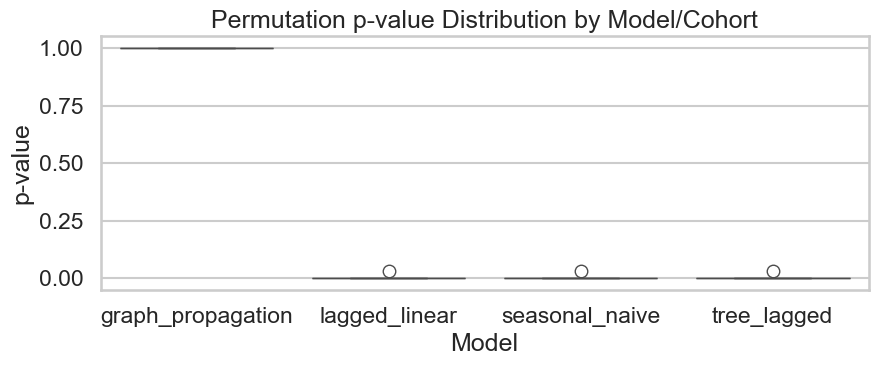

### Sensitivity Summary (Largest Absolute Deltas)

,sensitivity_axis,scope,aggregation,model,setting,metric,value,reference_value,delta_vs_reference,abs_delta
86,resolution,station_vs_community,station_community,seasonal_naive,aggregation_resolution,test_wmape,0.909232,0.292019,0.617213,0.617213
0,hyperparameter,graph_propagation_alpha,community,graph_propagation,alpha=0.0,validation_wmape,0.770632,0.261439,0.509193,0.509193
56,hyperparameter,baseline_hyperparameters,station,seasonal_naive,"{""seasonal_lag"": 56}",validation_wmape,1.392622,0.904613,0.488009,0.488009
90,threshold,sparse_vs_dense,station,seasonal_naive,sparse_quantile=0.25,test_wmape,1.344815,0.876044,0.468771,0.468771
84,resolution,station_vs_community,station_community,graph_propagation,aggregation_resolution,test_wmape,0.740800,0.292019,0.448781,0.448781
2,hyperparameter,graph_propagation_alpha,community,graph_propagation,alpha=0.05,validation_wmape,0.696481,0.261439,0.435042,0.435042
87,resolution,station_vs_community,station_community,tree_lagged,aggregation_resolution,test_wmape,0.608143,0.232901,0.375242,0.375242
4,hyperparameter,graph_propagation_alpha,community,graph_propagation,alpha=0.1,validation_wmape,0.633104,0.261439,0.371664,0.371664
91,threshold,sparse_vs_dense,station,tree_lagged,sparse_quantile=0.25,test_wmape,0.938595,0.582965,0.355630,0.355630
85,resolution,station_vs_community,station_community,lagged_linear,aggregation_resolution,test_wmape,0.607830,0.258576,0.349254,0.349254


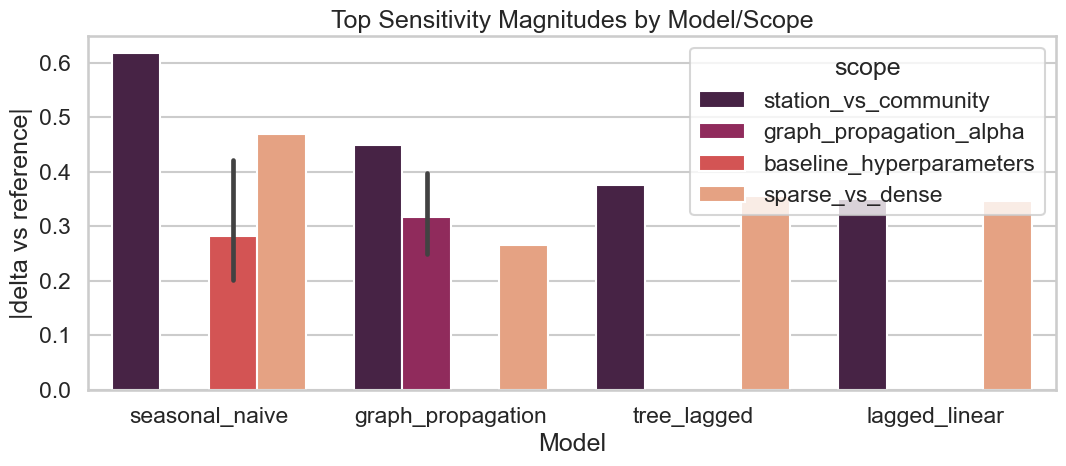

In [8]:
if not robustness.empty:
    display(Markdown('### Robustness Diagnostics'))
    summary_cols = ['model', 'cohort', 'test_station_wmape_mean', 'test_station_wmape_ci_lower', 'test_station_wmape_ci_upper', 'paired_sign_permutation_pvalue']
    cols = [c for c in summary_cols if c in robustness.columns]
    display(robustness[cols].sort_values([c for c in ['cohort', 'model'] if c in cols]))

    if 'paired_sign_permutation_pvalue' in robustness.columns:
        plt.figure(figsize=(9, 4))
        sns.boxplot(data=robustness, x='model', y='paired_sign_permutation_pvalue')
        plt.title('Permutation p-value Distribution by Model/Cohort')
        plt.xlabel('Model')
        plt.ylabel('p-value')
        plt.tight_layout()
        plt.show()
else:
    print('No robustness statistics file found.')

if not sensitivity.empty:
    display(Markdown('### Sensitivity Summary (Largest Absolute Deltas)'))
    if 'delta_vs_reference' in sensitivity.columns:
        sens_top = sensitivity.copy()
        sens_top['abs_delta'] = sens_top['delta_vs_reference'].abs()
        sens_top = sens_top.sort_values('abs_delta', ascending=False).head(20)
        display(sens_top)

        plt.figure(figsize=(11, 5))
        sns.barplot(data=sens_top, x='model', y='abs_delta', hue='scope', palette='rocket')
        plt.title('Top Sensitivity Magnitudes by Model/Scope')
        plt.xlabel('Model')
        plt.ylabel('|delta vs reference|')
        plt.tight_layout()
        plt.show()

In [9]:
expected_single_graphs = {'SD', 'DE', 'DC', 'ATD'}
expected_fusion_modes = {'equal', 'learned'}
expected_aggs = {'station', 'community'}

single_graphs_found = set()
single_aggs_found = set()
if not single_rows.empty:
    if 'graph_set' in single_rows.columns:
        for value in single_rows['graph_set'].dropna().astype(str):
            if '+' not in value and ',' not in value:
                single_graphs_found.add(value.strip().upper())
    if 'aggregation' in single_rows.columns:
        single_aggs_found = set(single_rows['aggregation'].dropna().astype(str))

fusion_modes_found = set()
fusion_aggs_found = set()
if not fusion_rows.empty:
    if 'fusion_mode' in fusion_rows.columns:
        fusion_modes_found = set(fusion_rows['fusion_mode'].dropna().astype(str))
    if 'aggregation' in fusion_rows.columns:
        fusion_aggs_found = set(fusion_rows['aggregation'].dropna().astype(str))

max_epoch_seen = 0
epoch_sources = []
for df_ in [single_rows, fusion_rows]:
    if not df_.empty and 'epochs_ran' in df_.columns:
        vals = pd.to_numeric(df_['epochs_ran'], errors='coerce').dropna()
        if len(vals) > 0:
            max_epoch_seen = max(max_epoch_seen, int(vals.max()))
            epoch_sources.extend(vals.tolist())

checklist = pd.DataFrame([
    {
        'criterion': 'Two model variants present (single and multi)',
        'status': bool(single_present and multi_present),
        'detail': f'single_present={single_present}, multi_present={multi_present}'
    },
    {
        'criterion': 'Single-graph diagnostics cover SD/DE/DC/ATD',
        'status': expected_single_graphs.issubset(single_graphs_found),
        'detail': f'found={sorted(single_graphs_found)}'
    },
    {
        'criterion': 'Fusion diagnostics include equal and learned',
        'status': expected_fusion_modes.issubset(fusion_modes_found),
        'detail': f'found={sorted(fusion_modes_found)}'
    },
    {
        'criterion': 'Coverage includes station and community diagnostics',
        'status': expected_aggs.issubset(single_aggs_found.union(fusion_aggs_found)),
        'detail': f'single_aggs={sorted(single_aggs_found)}, fusion_aggs={sorted(fusion_aggs_found)}'
    },
    {
        'criterion': 'Training curves are deep enough for diagnostics (max epoch > 1)',
        'status': bool(max_epoch_seen > 1),
        'detail': f'max_epoch_seen={max_epoch_seen}'
    },
])

display(Markdown('### Scientific Completeness Checklist'))
display(checklist)

if checklist['status'].all():
    display(Markdown('All completeness checks passed for diagnostics coverage.'))
else:
    display(Markdown('Some completeness checks are still missing. Recommended rerun for full scientific coverage:'))
    print('./.venv/Scripts/python.exe scripts/run_stgnn_milestones.py --single-graphs SD,DE,DC,ATD --fusion-graph-set SD,DE,DC,ATD --include-community --epochs 120 --patience 20 --hidden-dim 64 --batch-size 256 --max-train-windows 0 --device cuda --progress')

### Scientific Completeness Checklist

,criterion,status,detail
0,Two model variants present (single and multi),True,"single_present=True, multi_present=True"
1,Single-graph diagnostics cover SD/DE/DC/ATD,True,"found=['ATD', 'DC', 'DE', 'SD']"
2,Fusion diagnostics include equal and learned,True,"found=['equal', 'learned']"
3,Coverage includes station and community diagnostics,True,"single_aggs=['community', 'station'], fusion_aggs=['community', 'station']"
4,Training curves are deep enough for diagnostics (max epoch > 1),True,max_epoch_seen=20


All completeness checks passed for diagnostics coverage.